# Did The Sequence Extraction Work as Intended ??

In [2]:
import os
import sys

import pandas as pd
import matplotlib.pyplot as plt

In [3]:
BASE_DIR = "/nfs/scratch/pdb_dimers"

seqs_df = pd.read_csv(os.path.join(BASE_DIR, "entity_sequences.tsv"), sep="\t")

seqs_df.head()

,entity_name,cluster_id,sequence
0,10BL_1,20365_100,MEKVTKDDFESLDVLGKGXFAYVVLVRRIGTNEYYAMKVVNKQGLL...
1,10FT_1,10595_100,LGVDPSLQIDVLTELELGESTTGVRQVPGLHNGTKAFLFQDTPRSI...
2,10FT_2,17036_100,SLDQSTVLSSCLTSCVTNLGRQLDSGTRYNLSEACIHGCQFWNSVD...
3,10JU_1,65438_100,MEKVTKEDFETIDTLGKGXFAYVVLVRRVGTNNLYAMKVVNKQGLL...
4,10JU_2,65438_100,MEKVTKEDFETIDTLGKGSFAYVVLVRRVGTNNLYAMKVVNKQGLL...


### Duplicate IDs ??

In [4]:
mask = seqs_df["entity_name"].duplicated()
seqs_df[mask]

,entity_name,cluster_id,sequence


### Length Of The Sequences

In [5]:
seqs_df["length"] = seqs_df["sequence"].str.len()
seqs_df["length"].describe()

count    52254.000000
mean       252.380047
std        243.883688
min          1.000000
25%        113.000000
50%        216.000000
75%        335.000000
max       5247.000000
Name: length, dtype: float64

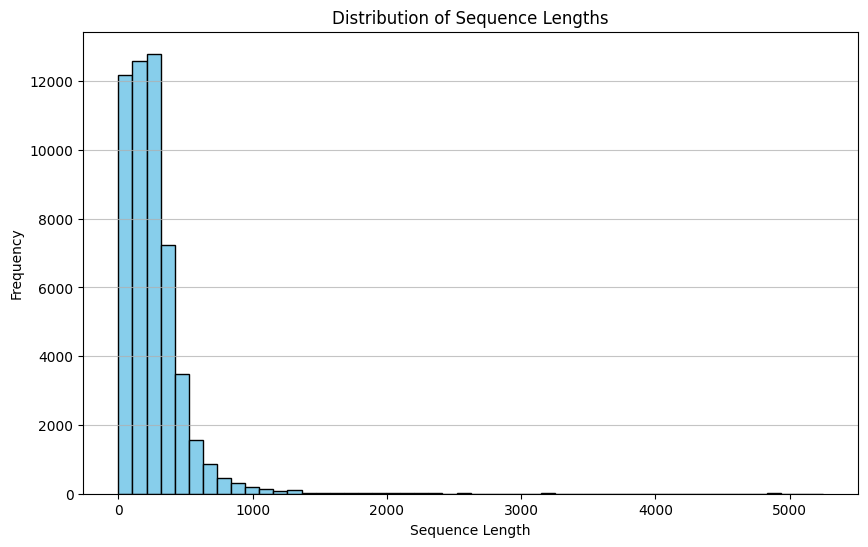

In [6]:
# Now a plot showing the distribution of sequence lengths
plt.figure(figsize=(10, 6))
plt.hist(seqs_df["length"], bins=50, color="skyblue", edgecolor="black")
plt.title("Distribution of Sequence Lengths")
plt.xlabel("Sequence Length")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.75)
plt.show()

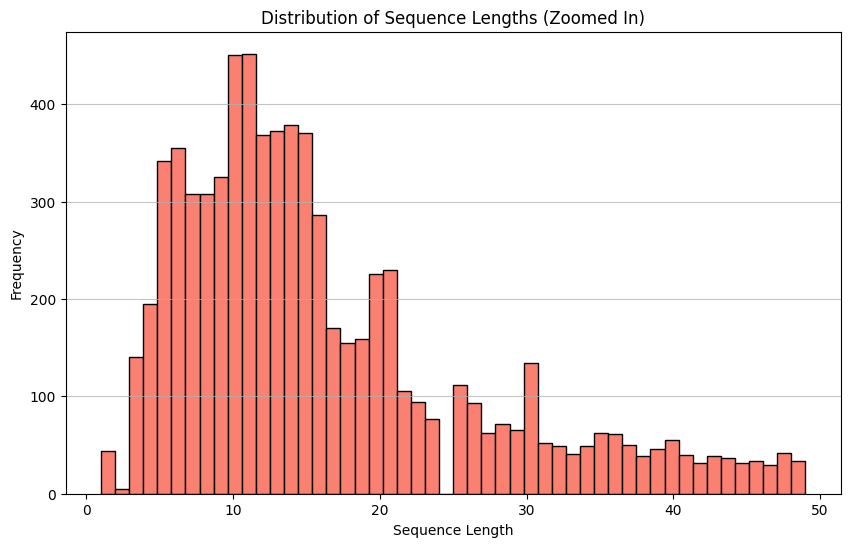

In [7]:
seqs_df_small = seqs_df[seqs_df["length"] < 50]
plt.figure(figsize=(10, 6))
plt.hist(seqs_df_small["length"], bins=50, color="salmon", edgecolor="black")
plt.title("Distribution of Sequence Lengths (Zoomed In)")
plt.xlabel("Sequence Length")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.75)
plt.show()

### How many are lost above certain sequence cutoffs ?

In [8]:
int_df = pd.read_csv(os.path.join(BASE_DIR, "selected_assemblies.tsv"), sep="\t")
int_df.head()

,assembly_id,pdb_id,assembly_number,entity_pair,uniprot_pair,uniprot_1,uniprot_2,dimer_type,cluster_pair_100pct,resolution_best_angstrom,modeled_polymer_monomer_count,experimental_method,oligomeric_count,download_url,local_filename
0,10BL-1,10BL,1,"10BL_1,10BL_1",Q4E2L0|Q4E2L0,Q4E2L0,Q4E2L0,homo,"20365_100,20365_100",2.60,664,X-ray,2,https://files.rcsb.org/download/10bl-assembly1...,10bl-assembly1.cif.gz
1,10FT-1,10FT,1,"10FT_1,10FT_2",Q99435|Q78DX7,Q99435,Q78DX7,hetero,"10595_100,17036_100",3.21,775,EM,2,https://files.rcsb.org/download/10ft-assembly1...,10ft-assembly1.cif.gz
2,10JU-1,10JU,1,"10JU_1,10JU_2",Q582V7|Q582V7,Q582V7,Q582V7,hetero,"65438_100,65438_100",2.15,522,X-ray,2,https://files.rcsb.org/download/10ju-assembly1...,10ju-assembly1.cif.gz
3,10JX-1,10JX,1,"10JX_1,10JX_1",A0A068NTE8|A0A068NTE8,A0A068NTE8,A0A068NTE8,homo,"65332_100,65332_100",1.47,282,X-ray,2,https://files.rcsb.org/download/10jx-assembly1...,10jx-assembly1.cif.gz
4,10KE-2,10KE,2,"10KE_1,10KE_1",Q7TTK0|Q7TTK0,Q7TTK0,Q7TTK0,homo,"86146_100,86146_100",1.70,679,X-ray,2,https://files.rcsb.org/download/10ke-assembly2...,10ke-assembly2.cif.gz


In [9]:
# how many sequences are longer than x residues?
x = 1000
print(f"Number of sequences longer than {x} residues: {(seqs_df['length'] > x).sum()}")

Number of sequences longer than 1000 residues: 629


In [10]:
# extract the entity names of sequences longer than x residues
long_entities = seqs_df[seqs_df["length"] > x]["entity_name"].tolist()
print(f"Entity names of sequences longer than {x} residues: {long_entities}")

Entity names of sequences longer than 1000 residues: ['10FT_2', '1A9X_1', '1BXR_1', '1C30_1', '1CE8_1', '1CS0_1', '1G8X_1', '1GTE_1', '1LSH_1', '1R27_1', '1V97_1', '2B5L_1', '2C42_1', '2CKJ_1', '2E1Q_1', '2E3T_1', '2HPI_1', '2J7N_1', '2NP0_1', '2VZ8_1', '2WK3_1', '2Y3A_1', '3AN1_1', '3BG5_1', '3BGA_1', '3E4A_1', '3EI3_1', '3EI4_1', '3GB8_1', '3HHM_1', '3I7H_1', '3I7K_1', '3I7L_1', '3I7N_1', '3I7O_1', '3I7P_1', '3I89_1', '3I8C_1', '3I8E_1', '3KSY_1', '3LXU_1', '3NC1_2', '3PVM_1', '3PVM_2', '3QMZ_1', '3S4W_1', '3S4W_2', '3S51_1', '3SPA_1', '3SYJ_1', '3TUV_1', '3UNC_1', '3V0B_1', '3V0B_2', '3VKG_1', '3W3W_1', '3W3X_1', '3W3Y_1', '3W3Z_1', '3ZEF_2', '3ZYV_1', '4A11_1', '4A55_1', '4A5W_1', '4AKG_1', '4ANJ_1', '4BGD_1', '4CI2_1', '4I43_2', '4IGL_1', '4II3_1', '4JPS_1', '4JSN_1', '4KSD_1', '4L23_1', '4LSG_1', '4M5D_1', '4NM9_1', '4Q9K_1', '4TTG_1', '4UHW_1', '4W8F_1', '4W8J_1', '4WAF_1', '4WD9_1', '4XC8_1', '4XJX_1', '4YOC_1', '4YTY_1', '4ZHJ_1', '4ZIQ_1', '4ZJ7_1', '4ZKT_1', '4ZKT_2', '5DCA_

In [11]:
# How many interactions are connected to these long sequences?
interactions_with_long_entities = int_df[
    int_df["entity_pair"].apply(lambda pair: any(entity in long_entities for entity in pair.split(",")))
]
print(f"Number of interactions connected to sequences longer than {x} residues: {len(interactions_with_long_entities)}")

Number of interactions connected to sequences longer than 1000 residues: 600


### How many are lost below a certain threshold?

In [17]:
int_df = pd.read_csv(os.path.join(BASE_DIR, "selected_assemblies.tsv"), sep="\t")
int_df.head()

,assembly_id,pdb_id,assembly_number,entity_pair,uniprot_pair,uniprot_1,uniprot_2,dimer_type,cluster_pair_100pct,resolution_best_angstrom,modeled_polymer_monomer_count,experimental_method,oligomeric_count,download_url,local_filename
0,10BL-1,10BL,1,"10BL_1,10BL_1",Q4E2L0|Q4E2L0,Q4E2L0,Q4E2L0,homo,"20365_100,20365_100",2.60,664,X-ray,2,https://files.rcsb.org/download/10bl-assembly1...,10bl-assembly1.cif.gz
1,10FT-1,10FT,1,"10FT_1,10FT_2",Q99435|Q78DX7,Q99435,Q78DX7,hetero,"10595_100,17036_100",3.21,775,EM,2,https://files.rcsb.org/download/10ft-assembly1...,10ft-assembly1.cif.gz
2,10JU-1,10JU,1,"10JU_1,10JU_2",Q582V7|Q582V7,Q582V7,Q582V7,hetero,"65438_100,65438_100",2.15,522,X-ray,2,https://files.rcsb.org/download/10ju-assembly1...,10ju-assembly1.cif.gz
3,10JX-1,10JX,1,"10JX_1,10JX_1",A0A068NTE8|A0A068NTE8,A0A068NTE8,A0A068NTE8,homo,"65332_100,65332_100",1.47,282,X-ray,2,https://files.rcsb.org/download/10jx-assembly1...,10jx-assembly1.cif.gz
4,10KE-2,10KE,2,"10KE_1,10KE_1",Q7TTK0|Q7TTK0,Q7TTK0,Q7TTK0,homo,"86146_100,86146_100",1.70,679,X-ray,2,https://files.rcsb.org/download/10ke-assembly2...,10ke-assembly2.cif.gz


In [18]:
# how many sequences are lonshorterger than x residues?
x = 50
print(f"Number of sequences shorter than {x} residues: {(seqs_df['length'] < x).sum()}")

Number of sequences shorter than 50 residues: 7281


In [19]:
# extract the entity names of sequences shorter than x residues
short_entities = seqs_df[seqs_df["length"] < x]["entity_name"].tolist()
print(f"Entity names of sequences shorter than {x} residues: {short_entities}")

Entity names of sequences shorter than 50 residues: ['10LG_2', '1A08_2', '1A09_2', '1A0M_1', '1A0N_1', '1A1R_2', '1A1U_1', '1A2X_2', '1A5H_1', '1A7F_1', '1A7F_2', '1A81_2', '1A93_1', '1A93_2', '1ABO_2', '1ABT_2', '1AFO_1', '1AL4_1', '1ALX_1', '1ALX_2', '1ALZ_1', '1ALZ_2', '1AN1_2', '1AOT_2', '1AOU_2', '1APM_2', '1APT_2', '1APU_2', '1APV_2', '1APW_2', '1AQ7_2', '1AS4_2', '1AV2_1', '1AVF_1', '1AVP_2', '1AWQ_2', '1AWR_2', '1AWS_2', '1AWT_2', '1AWU_2', '1AWV_2', '1AYA_2', '1AYB_2', '1AYC_2', '1AZE_2', '1AZG_1', '1B05_2', '1B07_2', '1B0H_2', '1B1H_2', '1B2H_2', '1B32_2', '1B3F_2', '1B3G_2', '1B3H_2', '1B3L_2', '1B40_2', '1B46_2', '1B4H_2', '1B4Z_2', '1B51_2', '1B52_2', '1B58_2', '1B5H_2', '1B5I_2', '1B5J_2', '1B6H_2', '1B7H_2', '1B8Q_2', '1B9J_2', '1BBZ_2', '1BC5_2', '1BCK_2', '1BDW_1', '1BE9_2', '1BEN_1', '1BEN_2', '1BH9_1', '1BHF_2', '1BI6_1', '1BI6_2', '1BJR_2', '1BM2_2', '1BMB_2', '1BOM_1', '1BOM_2', '1BON_1', '1BON_2', '1BQP_2', '1BR8_2', '1BS6_2', '1BS8_2', '1BSX_2', '1BW8_2', '1BXL_2

In [20]:
# How many interactions are connected to these short sequences?
interactions_with_short_entities = int_df[
    int_df["entity_pair"].apply(lambda pair: any(entity in short_entities for entity in pair.split(",")))
]
print(f"Number of interactions connected to sequences shorter than {x} residues: {len(interactions_with_short_entities)}")

Number of interactions connected to sequences shorter than 50 residues: 7051


### How many unknown residues in short sequences ?

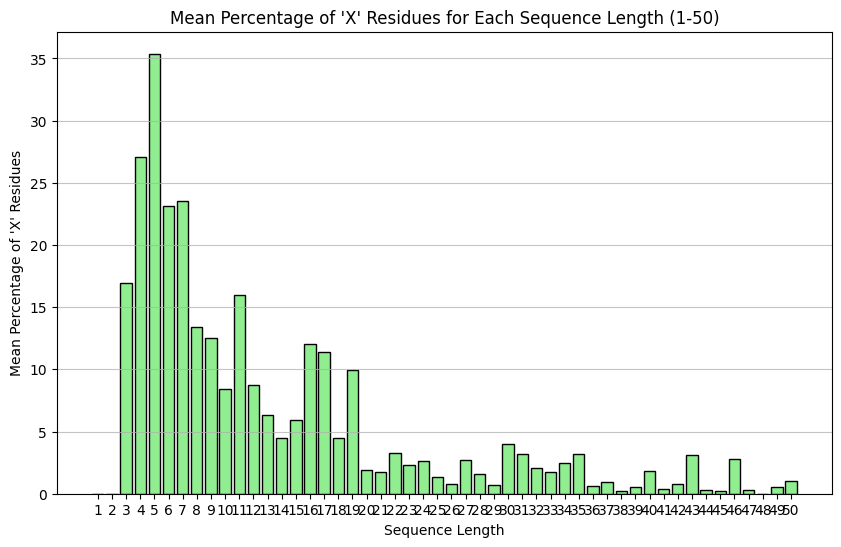

In [22]:
# Plot mean percentage of X residues for each sequence length from 1 to 10
mean_percentages = []
for length in range(1, 51):
    subset = seqs_df[seqs_df["length"] == length]
    if not subset.empty:
        mean_percentage = subset["sequence"].apply(lambda seq: seq.count("X") / len(seq) * 100).mean()
        mean_percentages.append(mean_percentage)
    else:
        mean_percentages.append(0)

plt.figure(figsize=(10, 6))
plt.bar(range(1, 51), mean_percentages, color="lightgreen", edgecolor="black")
plt.title("Mean Percentage of 'X' Residues for Each Sequence Length (1-50)")
plt.xlabel("Sequence Length")
plt.ylabel("Mean Percentage of 'X' Residues")
plt.xticks(range(1, 51))
plt.grid(axis="y", alpha=0.75)
plt.show()